In [ ]:
import matplotlib.pyplot as plt
import iris.plot as iplt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

from esmvalcore.dataset import Dataset
from esmvalcore.preprocessor import (
    extract_levels,
    extract_region,
    extract_time,
    extract_season,
    climate_statistics,
    convert_units,
    regrid
)

# --- 1. Settings & Paths ---
extent = [50, 180, -45, 30]  
# months = [5, 6, 7, 8, 9, 10] 

regions = {
    "BOB":  [85,  10, 5, 5],
    "NEQ":  [85,   5, 5, 5],
    "EEIO": [75,  -5, 10, 10],
    "WP":   [120, 10, 30, 10]
}



### Find data

In [ ]:
# datasets: GPCP day, ERA u,v day 20years #NCEP-NCAR-R1, ERA-Interim (Tier3), ERA5?
obs_pr = Dataset( 
    short_name='pr', dataset='NCEP-NCAR-R1',
    mip="day", project='OBS6', version='*',
    timerange="2000/2020", type='*', tier=2)

facetsn = {'short_name':'ua'}
obs_u = obs_pr.copy(**facetsn)
facetsn = {'short_name':'va'}
obs_va = obs_pr.copy(**facetsn)

len(obs_pr.files)

In [14]:
# model datasets - can also compare first and last 30 years
mod1pr = Dataset(
    short_name='pr', project='CMIP6', activity='*',
    mip="day", exp="historical", ensemble="r1i1p1f1",
    timerange="*", dataset="ACCESS-ESM1-5", grid="gn"
)

facets_mod = {'exp':'piControl', 'dataset':'ACCESS-CM2'}
mod2 = mod1pr.copy(**facets_mod)

## Mean state process

In [23]:
## handle in esmvalcore load and preprocess - for recipe
def mean_state(ds, is_model=False): #extent
    cube = ds.load()
    
    cube = extract_region(cube, start_longitude=extent[0], end_longitude=extent[1],
                          start_latitude=extent[2], end_latitude=extent[3])
    
    # if u,v plev=85000.
    if ds['short_name'] in ['ua','va']:
        cube = extract_levels(cube, [85000.], scheme='nearest')
    
    if is_model: #last 30 years
        end_year = cube.coord('time').units.num2date(cube.coord('time').points[-1]).year
        cube = extract_time(cube, start_year=end_year-29, start_month=1, start_day=1,
                            end_year=end_year, end_month=12, end_day=31)
    
    #season months = [5, 6, 7, 8, 9, 10] 
    cube = extract_season(cube, 'MJJASO')
    
    if ds['short_name'] == 'pr':
        cube = convert_units(cube, 'mm day-1')
    
    return climate_statistics(cube, operator='mean', period='full')

## Process data

In [26]:
# --- 2. Process Data ---
# Obs: Using variable names 'PREC' for GPCP and 'u'/'v' for ERA-Interim
mean_obs_pr = mean_state(obs_pr, is_model=False)
mean_obs_u  = mean_state(obs_u, is_model=False)
mean_obs_v  = mean_state(obs_va, is_model=False)

# Models: Last 30 Years
mean_m1_pr  = mean_state(mod1pr, is_model=True)
mean_m2_pr  = mean_state(mod2, is_model=True)

In [32]:
# Calculate Bias (Interpolate Obs to Model Grid) # regrid
bias_m1 = mean_m1_pr - regrid(mean_obs_pr, mean_m1_pr, scheme='linear')
bias_m2 = mean_m2_pr - regrid(mean_obs_pr, mean_m2_pr, scheme='linear')

In [38]:
# --- 3. Levels & Plotting ---
levs_obs = np.linspace(0, 16, 17)
levs_bias = np.unique(np.round(np.concatenate([
    np.arange(-6, -1, 2), 
    np.round(np.arange(-0.4, 0.5, 0.2), 2), 
    np.arange(2, 7, 2)
]), 1))

# regrid wind to lower resolution for mapping quivers
regrid_obs_u = regrid(mean_obs_u, target_grid='10x10', scheme='nearest')
regrid_obs_v = regrid(mean_obs_v, target_grid='10x10', scheme='nearest')

## Plotting 

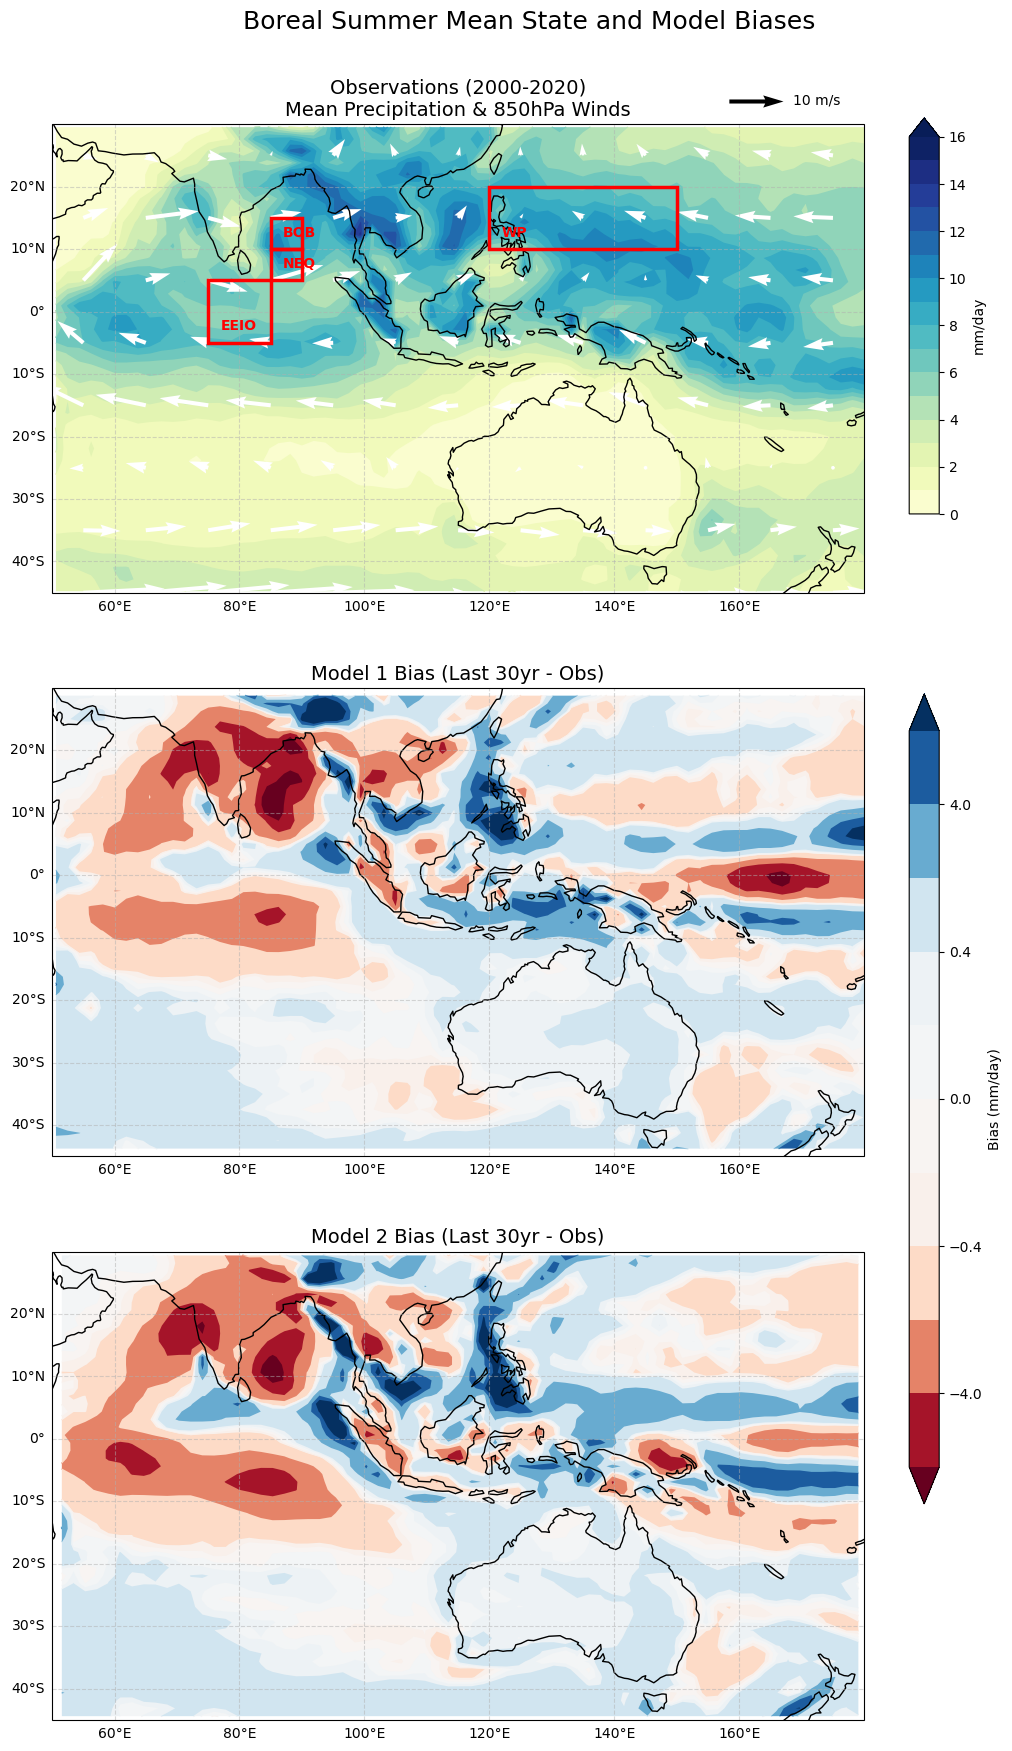

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18), subplot_kw={'projection': ccrs.PlateCarree()})

# Panel 1: Observation Mean State
im0 = iplt.contourf(mean_obs_pr, axes=axes[0], levels=levs_obs, cmap="YlGnBu", extend='max')

# Wind Arrows on Panel 1 
skip = 5 # regrid 10x10
q = iplt.quiver(regrid_obs_u, regrid_obs_v, axes=axes[0],
                   color='white', scale=150, width=0.005)
axes[0].quiverkey(q, 0.9, 1.05, 10, r'10 m/s', labelpos='E', coordinates='axes', color='black')

# Regional Boxes
for name, corner in regions.items():
    rect = mpatches.Rectangle((corner[0], corner[1]), corner[2], corner[3],
                              linewidth=2.5, edgecolor='red', facecolor='none', 
                              transform=ccrs.PlateCarree(), zorder=5)
    axes[0].add_patch(rect)
    axes[0].text(corner[0]+2, corner[1]+2, name, color='red', fontweight='bold', 
                 transform=ccrs.PlateCarree(), zorder=6)

axes[0].set_title("Observations (2000-2020)\nMean Precipitation & 850hPa Winds", fontsize=14)

# Panel 2: Model 1 Bias
im1 = iplt.contourf(bias_m1, axes=axes[1], levels=levs_bias, 
                       cmap="RdBu", extend='both')
axes[1].set_title("Model 1 Bias (Last 30yr - Obs)", fontsize=14)

# Panel 3: Model 2 Bias
im2 = iplt.contourf(bias_m2, axes=axes[2], levels=levs_bias, 
                       cmap="RdBu", extend='both')
axes[2].set_title("Model 2 Bias (Last 30yr - Obs)", fontsize=14)

for ax in axes:
    ax.coastlines()
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = gl.right_labels = False

# Layout & Colorbars
plt.tight_layout(rect=[0, 0, 0.85, 0.96])
cax0 = fig.add_axes([0.88, 0.70, 0.03, 0.22]) 
fig.colorbar(im0, cax=cax0, label='mm/day')
cax1 = fig.add_axes([0.88, 0.15, 0.03, 0.45]) 
fig.colorbar(im1, cax=cax1, label='Bias (mm/day)')

plt.suptitle("Boreal Summer Mean State and Model Biases", fontsize=18)
# plt.savefig(f"precip_gpcp_access_wind.png", dpi=300)
plt.show()